# Emulators and PINNs

In this notebook, we will explore the approximation of an ocean model using a neural network with physical constraints. The model used in this notebook is simple: a two-layer ocean model with atmospheric forcing.

**Learning Objectives**

1. Formulate a fully-connected neural network to approximate a physical model.
2. Implement a physical constraint into a loss function.
3. Implement learnable parameters as additional weights in the neural network.

**Import modules**

Begin by importing the modules to be used in this notebook.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from IPython.display import Image

In [2]:
torch.manual_seed(41)
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
print('Using device: '+device_name)
device = torch.device(device_name)

Using device: mps


In [3]:
images_dir = os.path.join('..','images')

## Motivation

Hydrodynamical ocean models are valuable tools in marine science and oceanography. They incorporate our knowledge of physical oceangraphic processes to simulation circulation and other oceanographic phenomenon in past years as well as the future. However, ocean models that incorporate all of these physical processes can be computationally expensive. With the recent development of machine learning hardware and algorithms, these tools have increasingly been used as alternatives to traditional modeling approaches. In this notebook, we will take a look at a simple ocean model example as a framework for understand how machine learning is being used in other large scale ocean model efforts.

### A Simple 2D Ocean Model

In this example, we'll consider a two-layer ocean as shown in the following diagram:

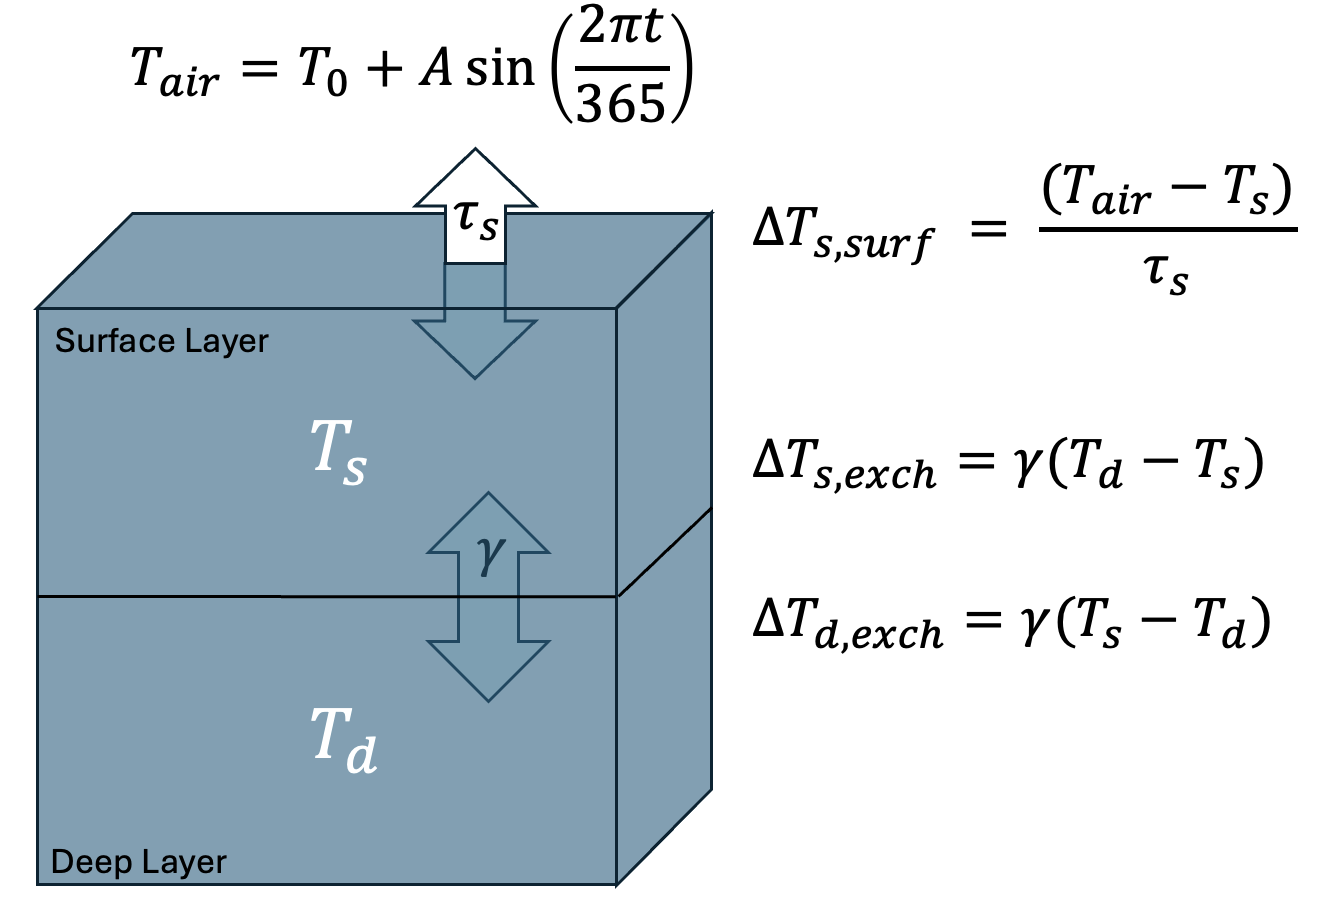

In [4]:
display(Image(filename=os.path.join(images_dir, 'two_layer_ocean_schematic.png'), width=500))

The surface layer of the ocean has a temperature $T_s$ and the deep layer of the ocean has a temperature $T_d$. The deep layer exchanges heat with the surface layer such that, in a given time interval, they change temperatures according to $\Delta T_s = \gamma (T_d - T_s)$ and $\Delta T_d = \gamma (T_s - T_d)$ where $\gamma$ is an exchange coefficient. The surface layer additionally exchanges heat with the air according to an additional parameterization $\Delta T_s = (T_{air}-T_s)/\tau_s$ where $\tau_s$ is a timescale for exchange. During the model simulation, $T_{air}$ is provided as a forcing parameter while $T_s$ and $T_d$ evolve through the simulation according to the physical exchanges and the variability in the air temperature.

We can code up this model run as follows:

In [5]:
# define the time parameters
dt = 1.0
n = 3650
t = np.arange(n)

# atmospheric forcing
T0 = 15.0
A = 6.0
T_air = T0 + A * np.sin(2 * np.pi * t / 365.0)

# ocean model parameters
tau_s = 30.0
gamma_true = 0.02

# ocean model initial conditions
Ts = np.zeros(n)
Td = np.zeros(n)
Ts[0] = 14.0
Td[0] = 10.0

# ocean model solution through time
for i in range(n - 1):

    # compute the forcing
    forcing = (T_air[i] - Ts[i]) / tau_s
    exch = gamma_true * (Ts[i] - Td[i])

    # compute the changes in temperature
    dTs = forcing - exch
    dTd = exch
    
    # update the temperature timeseries
    Ts[i + 1] = Ts[i] + dt * dTs
    Td[i + 1] = Td[i] + dt * dTd

Let's take a look at the solution:

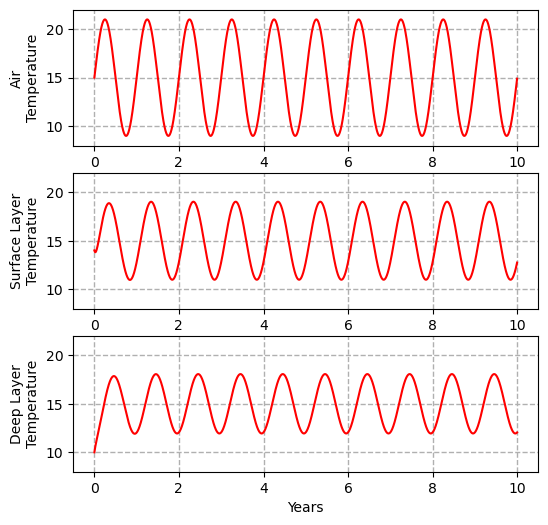

In [6]:
plt.figure(figsize=(6,6))

plt.subplot(3,1,1)
plt.plot(t/365, T_air,'r-')
plt.ylabel('Air\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)

plt.subplot(3,1,2)
plt.plot(t/365, Ts,'r-')
plt.ylabel('Surface Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)

plt.subplot(3,1,3)
plt.plot(t/365, Td,'r-')
plt.ylabel('Deep Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)
plt.xlabel('Years')
plt.show()

In the plots above, we can see that the temperatures of the surface and deep layers follow the air temperature variability, but with different amplitudes and a significant lag. The magnitudes of the lag and the amplitude differences result from exchange parameters $\tau_s$ and $\gamma$.

## An Ocean Model Emulator

The above model is pretty simple and we can simulate 10 years of ocean model temperature on our laptops in a fraction of a second. However, you could imagine that with more vertical and horizontal layers, more prognostic variables (e.g. salinity, momentum), and more physical processes in the model, it would take more computational power - and therefore time - to simulate the state of the ocean. This is widely the case for global ocean models that simulate the past state and future forecasts of the ocean. Thus, it would be great if we could **emulate** these processes using a neural network - that is, approximate the physics in our models without coding up the physics and solving for it explicitly. This would allow us to run our models much faster and examine results over longer time period.

In this example, we'll ask the following question: using the model output we have already generated above, could a neural network learn how to predict the next state of the ocean given its current state?

To formulate this type of model, let's begin by creating a set of input features and targets. Our input features will be the air, surface, and deep temperatures from the model. The targets will be the change in the surface and deep ocean temperatures (here, we are interpreting air temperature as a given forcing field for our model).

Written with symbols, our model $\mathcal{M}$ will be trained to predict the following:

$$
\mathcal{M} (T_{air}, T_s, T_d) = (\Delta T_s, \Delta T_d)
$$

Let's prepare our model data for training:

In [7]:
# make the X matrix with air, surface, and deep temperatures
X = np.column_stack([T_air[:-1], Ts[:-1], Td[:-1]])

# make a dY matrix with the differences of the surface and deep temperatures
dY = np.column_stack([Ts[1:] - Ts[:-1], Td[1:] - Td[:-1]])

As usual, we want to train our model on a given quantity of data and reserve some of our data for independent testing. Let's do that here:

In [8]:
split = 8*365 # first 8 years for training
X_train, X_test = X[:split], X[split:]
dY_train, dY_test = dY[:split], dY[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
dY_train_t = torch.tensor(dY_train, dtype=torch.float32).to(device)
dY_test_t = torch.tensor(dY_test, dtype=torch.float32).to(device)

### The Emulator Model

Next up, we'll create our emulator model. Here, we will create a neural network for the temperature changes in the surface and deep layers over the next timestep due to air-sea and inter-layer heat exchange. We will start this process naively and just give a simple fully-connected neural network our data and ask it to derive the patterns:

In [9]:
class OceanMLP(nn.Module):

    def __init__(self, hidden_dim=32):
        super().__init__()

        # write a small neural network
        self.forcing = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):

        # compute the temperature changes
        dY = self.forcing(x)
        return dY

### Training the Emulator

With our model coded up, we're now ready to train it just like our previous models:

In [10]:
# create the model and choose a gradient descent algorithm
ocean_emulator = OceanMLP(hidden_dim=32).to(device)
optimizer = torch.optim.Adam(ocean_emulator.parameters(), lr=1e-3)

# run a training loop, keeping track of losses
n_epochs = 3000

# keep track of the training losses
train_losses = []

for epoch in range(n_epochs):
    ocean_emulator.train()
    dY_model = ocean_emulator(X_train_t)

    # estimate the loss as the MSE
    loss = torch.mean((dY_model - dY_train_t) ** 2)

    # back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:4d} | Total: {loss.item():.6e}")

Epoch    0 | Total: 1.126480e-01
Epoch 1000 | Total: 1.614431e-06
Epoch 2000 | Total: 7.850334e-07


As usual, we should have a look at our losses:

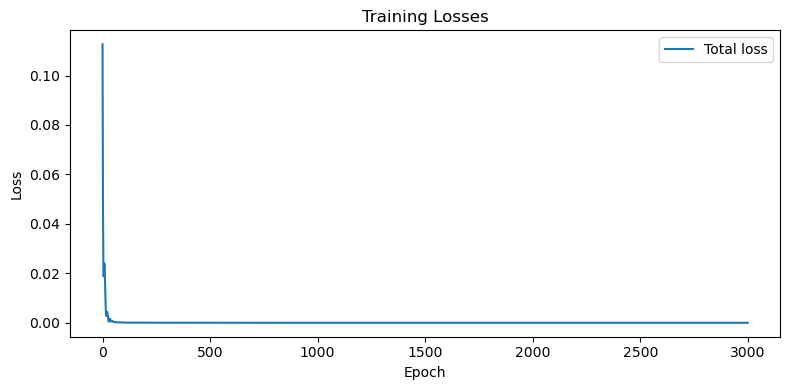

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.tight_layout()
plt.show()

Looks like we've converged. Let's check out how our model is working.

### Using the emulator for predictions

With our emulator trained on our existing data, next we can investigate using our model to estimate temperatures of the surface and deep ocean during times the model has not yet seen. Let's build a function to test our model:

In [12]:
def evaluate_emulator_on_test_set(model, Ts,Td,T_air):
    # make empty arrays for the solutions
    n_test = len(X_test)
    Ts_emul = np.zeros(n_test + 1)
    Td_emul = np.zeros(n_test + 1)
    
    # fill in the initial conditions
    Ts_emul[0] = Ts[split]
    Td_emul[0] = Td[split]
    
    # loop through the timesteps in the test data to predict temperatures
    ocean_emulator.eval()
    with torch.no_grad():
        for i in range(n_test):
    
            # each time through, we get the air, surface, and deep temperatures and put them in a tensor
            x_now = np.array([[T_air[split + i], Ts_emul[i], Td_emul[i]]], dtype=np.float32)
            x_now_t = torch.tensor(x_now, dtype=torch.float32).to(device)
    
            # then, use the tensor to predict the changes
            d_pred = model(x_now_t)
            d_pred = d_pred.cpu().numpy()[0]
    
            # update the next temperature with the changes
            Ts_emul[i + 1] = Ts_emul[i] + d_pred[0]
            Td_emul[i + 1] = Td_emul[i] + d_pred[1]
    return(Ts_emul, Td_emul)

With this in hand, let's see how we did:

In [13]:
# apply the function above to apply the neural network
# and emulate the simulation of Ts and Td
Ts_emul, Td_emul = evaluate_emulator_on_test_set(ocean_emulator, Ts,Td,T_air)

# for comparison, get the actual model results during the testing period
n_test = len(X_test)
Ts_true_test = Ts[split:split + n_test + 1]
Td_true_test = Td[split:split + n_test + 1]

# compute the RMSEs
rmse_Ts = np.sqrt(np.mean((Ts_true_test - Ts_emul) ** 2))
rmse_Td = np.sqrt(np.mean((Td_true_test - Td_emul) ** 2))

print(f"RMSE Ts: {rmse_Ts:.4f} C")
print(f"RMSE Td: {rmse_Td:.4f} C")

RMSE Ts: 0.0106 C
RMSE Td: 0.0119 C


Let's plot these up and compare through time:

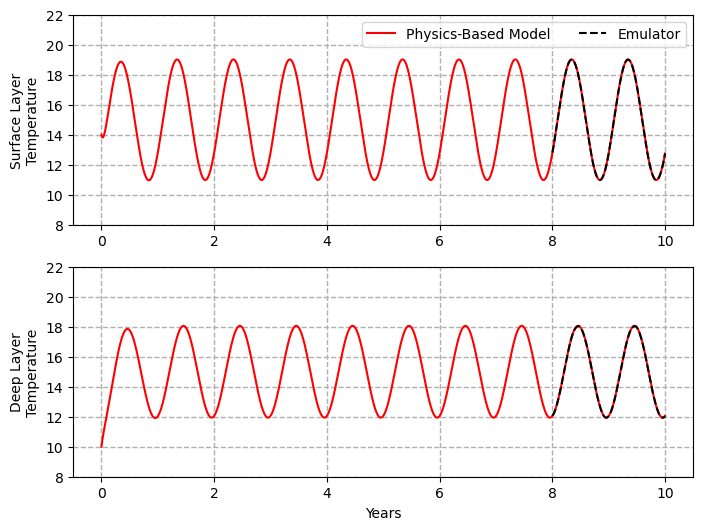

In [14]:
time_test = 8+np.arange(n_test+1)/365

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(t/365, Ts,'r-', label='Physics-Based Model')
plt.plot(time_test, Ts_emul, "k--", label='Emulator')
plt.legend(ncols=2)
plt.ylabel('Surface Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)

plt.subplot(2,1,2)
plt.plot(t/365, Td,'r-')
plt.plot(time_test, Td_emul, "k--")
plt.ylabel('Deep Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)
plt.xlabel('Years')
plt.show()

As we can see, the model does a fair job emulating the original model and is able to replicate the temperature results, even at "unseen" times! That's encouraging. What else can we use this model for?

## An Ocean Model Emulator with Physical Constraints

In the above model, we didn't really provide any of our oceanographic expertise - we just gave our neural network some data. Right now, it only learns from the data, and there is no guarantee that it will follow physical principles - e.g. conservation of heat. Let's see what issues we might run into by checking the model errors for the conservation of heat.

Note: here, we are going to formulate conservation of heat in the ocean as "conservation of temperature". This implicitly assumes that the specific heat is the same everywhere which is not true in general but is true for our model. Thus, we can omit the specific heat parameters as well as density and focus just on temperature.

In the deep layer, the only temperature change should be coming from the exchange of heat from the surface layer as modulated by the $\gamma$ parameter. We can calculate this over the test set as follows:

In [15]:
exchange_test = gamma_true * (Ts_emul - Td_emul)

The surface layer will also be modulated by this exchange in addition to the forcing from the atmosphere, which we can compute as follows:

In [16]:
forcing_test = (T_air[split:split + n_test+1] - Ts_emul) / tau_s

Now, if heat were conserved, then the differences in temperature from the emulator should match these changes. Let's compute the residuals in both layers between the emulator predictions and the physically expected changes:

In [17]:
dTs_emul = Ts_emul[1:] - Ts_emul[:-1]
dTd_emul = Td_emul[1:] - Td_emul[:-1]

surface_residual_test = dTs_emul - (forcing_test[:-1] - exchange_test[:-1])
deep_residual_test = dTd_emul - exchange_test[:-1]

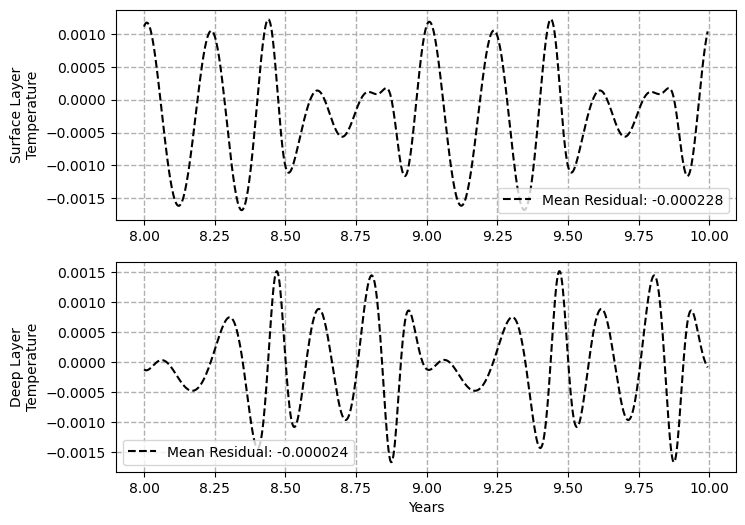

In [18]:
time_test = 8+np.arange(n_test+1)/365

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(time_test[:-1], surface_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(surface_residual_test)))
plt.legend()
plt.ylabel('Surface Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)

plt.subplot(2,1,2)
plt.plot(time_test[:-1], deep_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(deep_residual_test)))
plt.ylabel('Deep Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)
plt.legend()
plt.xlabel('Years')
plt.show()

Clearly, there is an issue here - heat is not being conserved!

### Implementing a Physical Constraint

Above, we saw that our model was not conserving heat but we didn't put anything into the model to ensure that it would. Since we just went through the work to build this in, let's modify our loss function to ensure this physical constraint is maintained.  

Since our model will be trained with a physics-based constraint, this type of model is called a **physics-informed neural network**.

In [19]:
ocean_emulator_2 = OceanMLP(hidden_dim=32).to(device)

optimizer = torch.optim.Adam(ocean_emulator_2.parameters(), lr=1e-3)

total_losses = []
data_losses = []
physics_losses = []
gammas = []

n_epochs = 3000

for epoch in range(n_epochs):
    ocean_emulator_2.train()
    optimizer.zero_grad()

    dY_model = ocean_emulator_2(X_train_t)

    # data mismatch
    data_loss = torch.mean((dY_model - dY_train_t) ** 2)

    # compute forcing and exchange
    dTs = dY_model[:, 0:1]
    dTd = dY_model[:, 1:2]
    Tair = X_train_t[:, 0:1]
    Ts_now = X_train_t[:, 1:2]
    Td_now = X_train_t[:, 2:3]
    forcing = (Tair - Ts_now) / tau_s
    exchange = gamma_true * (Ts_now - Td_now)

    # physical constraints
    surface_residual = dTs - (forcing - exchange)
    deep_residual = dTd - exchange
    phys_loss = torch.mean(surface_residual**2) + torch.mean(deep_residual**2)

    # compute the total loss as the combination of a data loss and a physics loss
    total_loss = data_loss + 1e7*phys_loss 
    total_loss.backward()
    optimizer.step()

    total_losses.append(total_loss.item())
    data_losses.append(data_loss.item())
    physics_losses.append(phys_loss.item())

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total Loss: {total_loss.item():.6e} | "
            f"Data Loss: {data_loss.item():.6e} | "
            f"Physics Loss: {phys_loss.item():.6e}"
        )

Epoch    0 | Total Loss: 6.112801e+05 | Data Loss: 3.056400e-02 | Physics Loss: 6.112801e-02
Epoch 1000 | Total Loss: 1.421821e+01 | Data Loss: 7.109105e-07 | Physics Loss: 1.421821e-06
Epoch 2000 | Total Loss: 4.645227e+00 | Data Loss: 2.322613e-07 | Physics Loss: 4.645227e-07


Since we have two different components of our loss in this model, we can plot each of them individually along with the total loss:

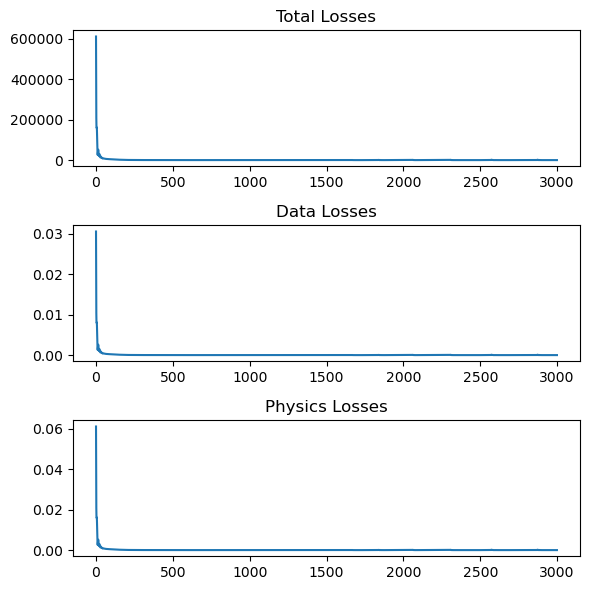

In [20]:
plt.figure(figsize=(6,6))

plt.subplot(3,1,1)
plt.title('Total Losses')
plt.plot(total_losses)

plt.subplot(3,1,2)
plt.title('Data Losses')
plt.plot(data_losses)

plt.subplot(3,1,3)
plt.title('Physics Losses')
plt.plot(physics_losses)

plt.tight_layout()

plt.show()

Let's see how our new model is performing with its residuals. Using the same code as above, we'll compute the residuals:

In [21]:
Ts_emul, Td_emul = evaluate_emulator_on_test_set(ocean_emulator_2, Ts,Td,T_air)

In [22]:
dTs_emul = Ts_emul[1:] - Ts_emul[:-1]
dTd_emul = Td_emul[1:] - Td_emul[:-1]

forcing_test = (T_air[split:split + n_test+1] - Ts_emul) / tau_s
exchange_test = gamma_true * (Ts_emul - Td_emul)

surface_residual_test = dTs_emul - (forcing_test[:-1] - exchange_test[:-1])
deep_residual_test = dTd_emul - exchange_test[:-1]

Then, we'll plot them in the same way:

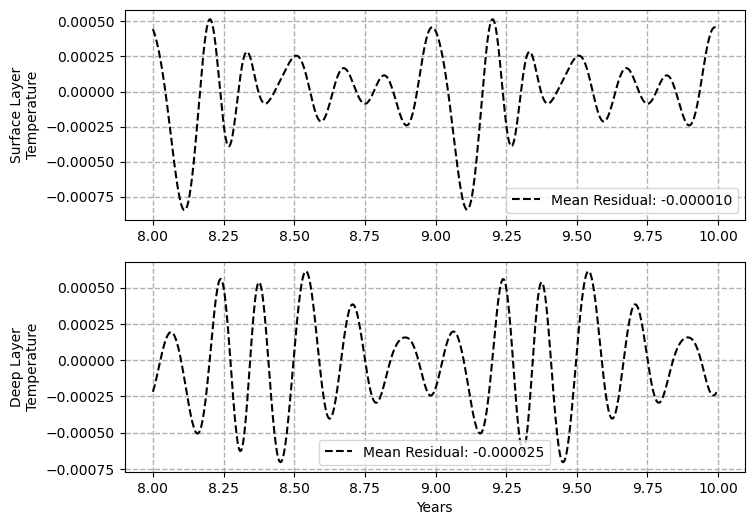

In [23]:
time_test = 8+np.arange(n_test+1)/365

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(time_test[:-1], surface_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(surface_residual_test)))
plt.legend()
plt.ylabel('Surface Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)

plt.subplot(2,1,2)
plt.plot(time_test[:-1], deep_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(deep_residual_test)))
plt.ylabel('Deep Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)
plt.legend()
plt.xlabel('Years')
plt.show()

As we can see in this example, our errors for heat conservation have been significantly reduced with the inclusion of the physical constraint in the loss function. However, it should be noted that the emulator is still making errors. It is important to keep this in mind when using emulators for approximating a parameterized hydrodynamical model.

## An Ocean Model Emulator with Learnable Parameters

In the above models, we created a small neural network that could emulate the original model that was coded with physical parameterizations. In the first implementation, we didn't care much about the underlying physics - e.g. what the $\gamma$ parameter was and what its value was. In the second implementation, we considered these processes but assumed that we knew with certainty what the parameter values should be - these were used in the physical constraints in the loss function. However, we don't often know what these parameters should be. One improvement we could make is to allow the model to learn this parameter from the data. This would allow the model to be used in other circumstances where there were real observations, say, from a mooring in the deep layer. 

Let's see how we can build learning of the $\gamma$ parameter into our model.

In [24]:
class OceanMLPwithGamma(nn.Module):

    def __init__(self, hidden_dim=32, gamma_init=0.01):
        super().__init__()

        # write a small neural network for the forcing term
        self.forcing = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )

        # gamma is a parameter of the model
        gamma_init = torch.log(torch.expm1(torch.tensor(gamma_init)))
        self.gamma_raw = nn.Parameter(torch.tensor([gamma_init], dtype=torch.float32))

    def forward(self, x):

        # compute the surface forcing using the neural network
        dY = self.forcing(x)

        # ensure gamma is positive
        self.gamma = torch.nn.functional.softplus(self.gamma_raw)

        return dY, self.gamma

This model is nearly identical to the previous model but there are a few changes:
1. $\gamma$ is now a parameter of the model and is initialized with a `gamma_init` variable. 
2. Since gamma can vary and become negative but it is kept positive with the "softplus" function ($f(x) = \log(1+e^x)$)
3. $\gamma$ is also returned from the model for comparison

Let's run a training loop for this model and see how it works:

In [25]:
ocean_emulator_3 = OceanMLPwithGamma(hidden_dim=32, gamma_init=0.01).to(device)

optimizer = torch.optim.Adam(ocean_emulator_3.parameters(), lr=1e-3)

total_losses = []
data_losses = []
physics_losses = []
gammas = []

n_epochs = 3001

for epoch in range(n_epochs):
    ocean_emulator_3.train()
    optimizer.zero_grad()

    dY_model, gamma_model = ocean_emulator_3(X_train_t)

    # data mismatch
    data_loss = torch.mean((dY_model - dY_train_t) ** 2)

    # compute forcing and exchange
    dTs = dY_model[:, 0:1]
    dTd = dY_model[:, 1:2]
    Tair = X_train_t[:, 0:1]
    Ts_now = X_train_t[:, 1:2]
    Td_now = X_train_t[:, 2:3]
    forcing = (Tair - Ts_now) / tau_s
    exchange = gamma_model * (Ts_now - Td_now)

    # physical constraints
    surface_residual = dTs - (forcing - exchange)
    deep_residual = dTd - exchange
    
    phys_loss = torch.mean(surface_residual**2) + torch.mean(deep_residual**2)
    
    total_loss = data_loss + phys_loss 
    total_loss.backward()
    optimizer.step()

    total_losses.append(total_loss.item())
    data_losses.append(data_loss.item())
    physics_losses.append(phys_loss.item())
    gammas.append(gamma_model.item())

    if epoch % 300 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total Loss: {total_loss.item():.6e} | "
            f"Data Loss: {data_loss.item():.6e} ")
        print(
            f"             Physics Loss: {phys_loss.item():.6e} | "
            f"Gamma: {gamma_model.item():.5f}")

Epoch    0 | Total Loss: 2.141767e-01 | Data Loss: 7.103936e-02 
             Physics Loss: 1.431374e-01 | Gamma: 0.01000
Epoch  300 | Total Loss: 1.768533e-04 | Data Loss: 1.060307e-04 
             Physics Loss: 7.082261e-05 | Gamma: 0.01244
Epoch  600 | Total Loss: 4.880302e-05 | Data Loss: 2.999479e-05 
             Physics Loss: 1.880824e-05 | Gamma: 0.01588
Epoch  900 | Total Loss: 9.084476e-06 | Data Loss: 4.680813e-06 
             Physics Loss: 4.403663e-06 | Gamma: 0.01861
Epoch 1200 | Total Loss: 2.705194e-06 | Data Loss: 9.685476e-07 
             Physics Loss: 1.736646e-06 | Gamma: 0.01973
Epoch 1500 | Total Loss: 2.675186e-06 | Data Loss: 8.988201e-07 
             Physics Loss: 1.776366e-06 | Gamma: 0.01996
Epoch 1800 | Total Loss: 1.201833e-06 | Data Loss: 4.008094e-07 
             Physics Loss: 8.010240e-07 | Gamma: 0.01999
Epoch 2100 | Total Loss: 1.199214e-06 | Data Loss: 3.994346e-07 
             Physics Loss: 7.997797e-07 | Gamma: 0.01999
Epoch 2400 | Total Loss:

This training loop is almost identical to the previous one. The only difference is that we now use `gamma_model` in the computation of the inter-layer exchanges. When the backward propagation updates the model weights, this model parameter is also updated along the way. We saved this parameter during the loop so we can also have a look at it here:

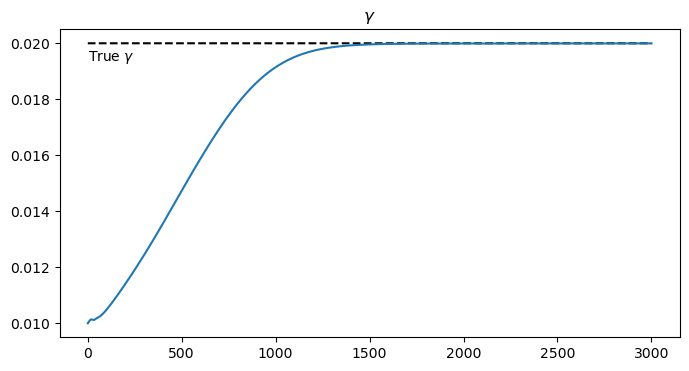

In [26]:
plt.figure(figsize=(8,4))
plt.title('$\\gamma$')
plt.plot(gamma_true*np.ones((len(gammas),)),'k--', label='True $\\gamma$')
plt.text(0,0.99*gamma_true,'True $\\gamma$', va='top')
plt.plot(gammas, label='Model $\\gamma$')
plt.show()

As we can see, the model has learned an appropriate value for this parameter *in addition* to learning how to emulate the model results.

Let's see how the emulator is performing. Again, we will compute the model results using the emulator through time:

In [27]:
# make empty arrays for the solutions
n_test = len(X_test)
Ts_emul = np.zeros(n_test + 1)
Td_emul = np.zeros(n_test + 1)

# fill in the initial conditions
Ts_emul[0] = Ts[split]
Td_emul[0] = Td[split]

# loop through the timesteps in the test data to predict temperatures
ocean_emulator.eval()
with torch.no_grad():
    for i in range(n_test):

        # each time through, we get the air, surface, and deep temperatures and put them in a tensor
        x_now = np.array([[T_air[split + i], Ts_emul[i], Td_emul[i]]], dtype=np.float32)
        x_now_t = torch.tensor(x_now, dtype=torch.float32).to(device)

        # then, use the tensor to predict the changes
        d_pred, _ = ocean_emulator_3(x_now_t)
        d_pred = d_pred.cpu().numpy()[0]

        # update the next temperature with the changes
        Ts_emul[i + 1] = Ts_emul[i] + d_pred[0]
        Td_emul[i + 1] = Td_emul[i] + d_pred[1]

Next, we'll plot it agains the true solution:

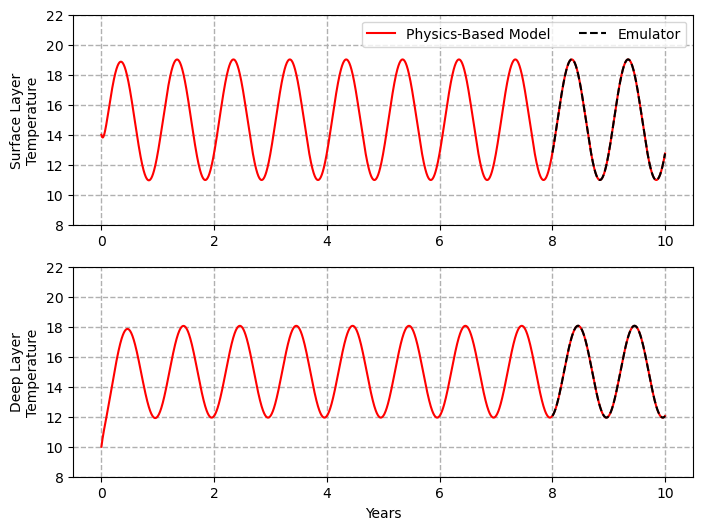

In [28]:
time_test = 8+np.arange(n_test+1)/365

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(t/365, Ts,'r-', label='Physics-Based Model')
plt.plot(time_test, Ts_emul, "k--", label='Emulator')
plt.legend(ncols=2)
plt.ylabel('Surface Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)

plt.subplot(2,1,2)
plt.plot(t/365, Td,'r-')
plt.plot(time_test, Td_emul, "k--")
plt.ylabel('Deep Layer\nTemperature')
plt.ylim([8,22])
plt.grid(linestyle='--', linewidth=1)
plt.xlabel('Years')
plt.show()

As anticipated, these results look pretty good. As a final check, we can take another look at the residuals to check on our conservation of heat:

In [29]:
dTs_emul = Ts_emul[1:] - Ts_emul[:-1]
dTd_emul = Td_emul[1:] - Td_emul[:-1]

forcing_test = (T_air[split:split + n_test+1] - Ts_emul) / tau_s
exchange_test = gamma_true * (Ts_emul - Td_emul)

surface_residual_test = dTs_emul - (forcing_test[:-1] - exchange_test[:-1])
deep_residual_test = dTd_emul - exchange_test[:-1]

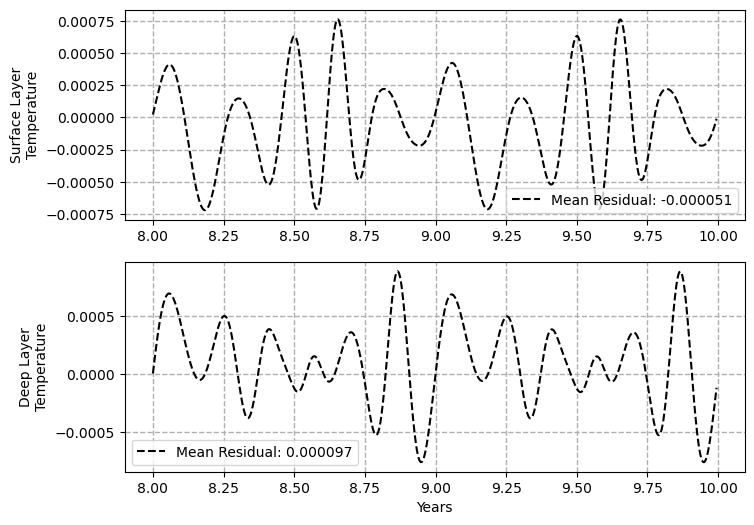

In [30]:
time_test = 8+np.arange(n_test+1)/365

plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(time_test[:-1], surface_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(surface_residual_test)))
plt.legend()
plt.ylabel('Surface Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)

plt.subplot(2,1,2)
plt.plot(time_test[:-1], deep_residual_test, "k--", 
         label='Mean Residual: '+'{:.6f}'.format(np.mean(deep_residual_test)))
plt.ylabel('Deep Layer\nTemperature')
plt.grid(linestyle='--', linewidth=1)
plt.legend()
plt.xlabel('Years')
plt.show()

### Key Takeaways

1. Emulators use neural networks to approximate physical parameterizations in hydrodynamical models.
2. Physical constraints in the loss function help ensure the model is not violating physical principles, such as the conservation of heat, in the solution.
3. Emulators can also be formulated to learn important model parameters from data rather than prescribing them directly.